
=== Provider x Automation Depth (CI-executing adopters) ===

       Provider  Fully_Auto  Semi_Auto  Total
 GitHub Actions         217         44    261
      Travis CI          97         16    113
       CircleCI          25          4     29
      GitLab CI           8          2     10
Azure Pipelines           3          0      3
        Bitrise           3          0      3
         Cirrus           3          0      3
       AppVeyor           1          1      2

Saved table to: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\observation3_provider_table.csv
Saved stacked bar chart to: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\observation3_provider_stacked.png


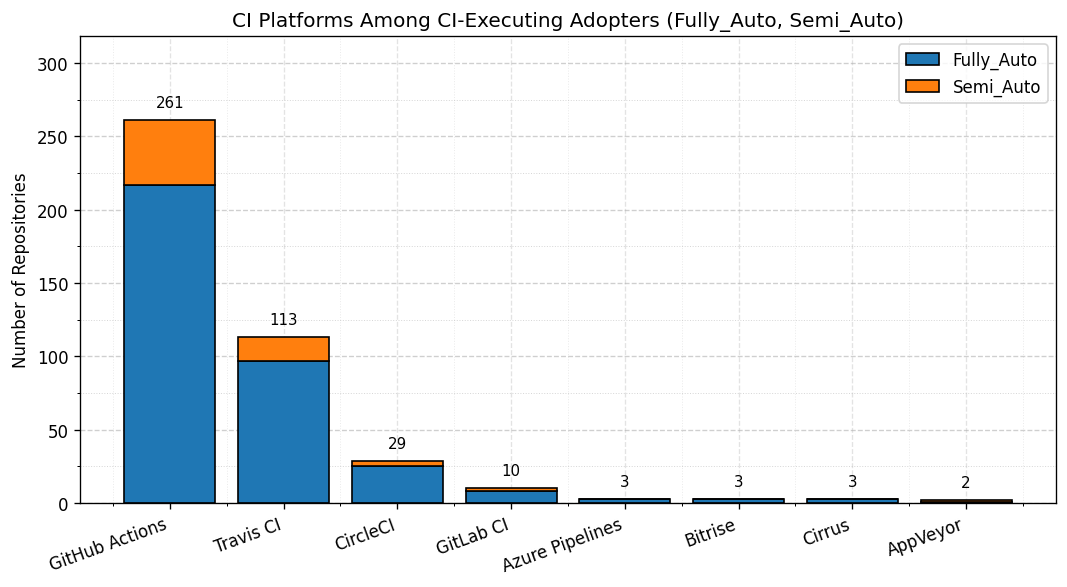

In [8]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ==================== CONFIG ====================
BASE_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet")
CSV_PATH = BASE_DIR / "5.0_Total_Repo.csv"   # change if your filename differs

# Provider name -> list of regexes (matched against column names, case-insensitive)
PROVIDER_PATTERNS = {
    "GitHub Actions": [r"github[_\- ]?actions?", r"\bgha\b"],
    "Travis CI":      [r"travis"],
    "CircleCI":       [r"circle[_\- ]?ci", r"\bcircle\b"],
    "GitLab CI":      [r"gitlab[_\- ]?ci", r"\bgitlab\b"],
    "Azure Pipelines":[r"azure[_\- ]?(pipelines?|devops)", r"\bazp\b"],
    "Bitrise":        [r"bitrise"],
    "Cirrus":         [r"cirrus"],
    "AppVeyor":       [r"appveyor"],
}
# =================================================

# ---------- helpers ----------
def normalize_depth(val: str) -> str | None:
    """Normalize RQ1_F2 depth labels to Fully_Auto / Semi_Auto or None."""
    s = re.sub(r"\s+", "_", str(val).strip().lower())
    if s in {"fully_auto", "fully"}:
        return "Fully_Auto"
    if s in {"semi_auto", "semi", "partial"}:
        return "Semi_Auto"
    # ignore Build_Only/None/etc. since we only want CI-executing adopters (FA ∪ SA)
    return None

def truthy(x) -> bool:
    """Interpret heterogeneous booleans/flags."""
    s = str(x).strip().lower()
    return s not in {"", "0", "false", "f", "no", "n", "none", "nan"}

def find_provider_columns(df: pd.DataFrame) -> dict[str, list[str]]:
    """Return mapping: Provider -> [matching column names]."""
    lowermap = {c.lower(): c for c in df.columns}
    found = {}
    for provider, pats in PROVIDER_PATTERNS.items():
        cols = []
        for lc, orig in lowermap.items():
            if any(re.search(p, lc, flags=re.I) for p in pats):
                cols.append(orig)
        found[provider] = cols
    return found

# ---------- load ----------
df = pd.read_csv(CSV_PATH, dtype=str)

# sanity check
if "RQ1_F2" not in df.columns:
    raise KeyError(f"Missing required column 'RQ1_F2'. Available: {list(df.columns)}")

# ---------- filter to CI-executing adopters (FA ∪ SA) ----------
df["_depth"] = df["RQ1_F2"].apply(normalize_depth)
ci_adopters = df[df["_depth"].notna()].copy()

# ---------- locate provider columns ----------
provider_cols = find_provider_columns(ci_adopters)

# If a provider has no detected columns, keep it with empty list (counts will be 0).
# For each provider, mark a repo as "uses provider" if ANY of its columns for that provider is truthy.
def provider_mask(df_in: pd.DataFrame, cols: list[str]) -> pd.Series:
    if not cols:
        return pd.Series(False, index=df_in.index)
    acc = pd.Series(False, index=df_in.index)
    for c in cols:
        acc = acc | df_in[c].apply(truthy)
    return acc

# ---------- build counts ----------
rows = []
display_order = ["GitHub Actions", "Travis CI", "CircleCI", "GitLab CI", "Azure Pipelines", "Bitrise", "Cirrus", "AppVeyor"]

for provider in display_order:
    mask = provider_mask(ci_adopters, provider_cols.get(provider, []))
    sub = ci_adopters[mask]
    # counts per depth
    fa = int((sub["_depth"] == "Fully_Auto").sum())
    sa = int((sub["_depth"] == "Semi_Auto").sum())
    rows.append({"Provider": provider, "Fully_Auto": fa, "Semi_Auto": sa, "Total": fa + sa})

table_df = pd.DataFrame(rows)

# ---------- print & save table ----------
print("\n=== Provider x Automation Depth (CI-executing adopters) ===\n")
print(table_df.to_string(index=False))

out_table_csv = BASE_DIR / "observation3_provider_table.csv"
table_df.to_csv(out_table_csv, index=False, encoding="utf-8-sig")
print(f"\nSaved table to: {out_table_csv}")

# ---------- stacked bar chart with horizontal & vertical buddy grids ----------
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)

x = range(len(table_df))
fa_vals = table_df["Fully_Auto"].values
sa_vals = table_df["Semi_Auto"].values
totals  = table_df["Total"].values

bars_fa = ax.bar(x, fa_vals, label="Fully_Auto", edgecolor="black")
bars_sa = ax.bar(x, sa_vals, bottom=fa_vals, label="Semi_Auto", edgecolor="black")

ax.set_xticks(list(x))
ax.set_xticklabels(table_df["Provider"], rotation=20, ha="right")
ax.set_ylabel("Number of Repositories")
ax.set_title("CI Platforms Among CI-Executing Adopters (Fully_Auto, Semi_Auto)")
ax.legend()

# Headroom so labels don't clip
top = max(totals) if len(totals) else 1
ax.set_ylim(0, top * 1.22)
ax.margins(y=0.05)

# ----- Buddy grids: major + minor on BOTH axes -----
ax.set_axisbelow(True)  # grids behind bars

# Y (horizontal grids)
ax.yaxis.set_minor_locator(AutoMinorLocator(n=2))  # 2 minor per major
ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", axis="y", linestyle=":",  linewidth=0.6, alpha=0.5)

# X (vertical grids)
# Major at bar centers (integer ticks), minor in-between
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=2))
ax.grid(True, which="major", axis="x", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(True, which="minor", axis="x", linestyle=":",  linewidth=0.6, alpha=0.25)

# Total labels on top of stacks
for i, total in enumerate(totals):
    ax.annotate(
        f"{int(total)}",
        xy=(i, total),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

fig.tight_layout()
out_png = BASE_DIR / "observation3_provider_stacked.png"
fig.savefig(out_png, bbox_inches="tight")
print(f"Saved stacked bar chart to: {out_png}")

plt.show()








In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ==================== CONFIG ====================
BASE_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet")
CSV_PATH = BASE_DIR / "5.0_Total_Repo.csv"

# Output filenames (match your LaTeX placeholders)
OUT_ENV_PNG = BASE_DIR / "rq1_exec_envs.png"   # Execution environments
OUT_TRG_PNG = BASE_DIR / "rq1_triggers.png"    # Triggers (optional separate figure)
# =================================================

# ---------- Helpers ----------
def truthy_adopter(x: str) -> bool:
    s = str(x).strip().lower()
    return s in {"adopter", "1", "true", "t", "yes", "y"}

def norm_depth(x: str):
    s = re.sub(r"\s+", "_", str(x).strip().lower())
    if s in {"fully_auto", "fully"}: return "Fully_Auto"
    if s in {"semi_auto", "semi", "partial"}: return "Semi_Auto"
    if s in {"build_only", "build"}: return "Build_Only"
    return None

def pick_first_existing(df: pd.DataFrame, candidates: list[str]) -> str:
    present = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in present:
            return present[cand.lower()]
    raise KeyError(
        f"None of the expected columns found. Looked for: {candidates}\n"
        f"Available columns: {list(df.columns)}"
    )

def norm_exec_env(x: str) -> str:
    s = str(x).strip().lower()
    # map common variants
    if "gmd" in s or "managed" in s:
        return "Managed Virtual Device"
    if "third" in s or "3p" in s or "lab" in s or "firebase" in s or "browserstack" in s or "sauce" in s:
        return "Third-Party Device Lab"
    if "real" in s or "physical" in s:
        return "Real Device"
    if "emulator" in s or "avd" in s or "sdkmanager" in s or "avdmanager" in s:
        return "Local Emulator"
    if not s or s == "nan":
        return "Unknown"
    # fallback
    return s.title()

def norm_trigger(x: str) -> str:
    s = str(x).strip().lower()
    if "gradle" in s:
        return "Gradle"
    if "adb" in s or "am instrument" in s:
        return "ADB"
    if "gcloud" in s or "flank" in s or "sauce" in s or "appcenter" in s or "bstack" in s:
        return "3P CLI"
    if not s or s == "nan":
        return "Unknown"
    return s.title()

def bar_with_labels(categories, values, title, ylabel, outfile):
    fig, ax = plt.subplots(figsize=(7.2, 4.0), dpi=120)
    x = range(len(categories))
    bars = ax.bar(x, values, edgecolor="black")
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # headroom + labels
    top = max(values) if values else 1
    ax.set_ylim(0, top * 1.22)
    ax.margins(y=0.05)

    # buddy grids (major + minor) on both axes, behind bars
    from matplotlib.ticker import AutoMinorLocator, MultipleLocator
    ax.set_axisbelow(True)
    ax.yaxis.set_minor_locator(AutoMinorLocator(n=2))
    ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(True, which="minor", axis="y", linestyle=":",  linewidth=0.6, alpha=0.5)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(AutoMinorLocator(n=2))
    ax.grid(True, which="major", axis="x", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(True, which="minor", axis="x", linestyle=":",  linewidth=0.5, alpha=0.25)

    for i, v in enumerate(values):
        ax.annotate(f"{int(v)}",
                    xy=(i, v), xytext=(0, 6),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9,
                    clip_on=False)

    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    print(f"Saved: {outfile}")
    plt.close(fig)

# ---------- Load ----------
df = pd.read_csv(CSV_PATH, dtype=str)

# Required columns
adopter_col = pick_first_existing(df, ["RQ1_F1", "adopter", "is_adopter"])
depth_col   = pick_first_existing(df, ["RQ1_F2", "automation_depth", "depth"])

# Optional columns (try multiple common names)
exec_env_col_candidates = [
    "execution_environment", "exec_env", "rq1_exec_env", "executionenv", "environment"
]
trigger_col_candidates = [
    "test_invocation", "trigger", "rq1_trigger", "invocation", "runner"
]

exec_env_col = pick_first_existing(df, exec_env_col_candidates)
trigger_col  = pick_first_existing(df, trigger_col_candidates)

# ---------- Filter to CI-executing adopters (FA ∪ SA) ----------
df["_is_adopter"] = df[adopter_col].apply(truthy_adopter)
df["_depth"] = df[depth_col].apply(norm_depth)
fa_sa = df[df["_is_adopter"] & df["_depth"].isin(["Fully_Auto", "Semi_Auto"])].copy()

if fa_sa.empty:
    raise RuntimeError("No CI-executing adopters found (Fully_Auto ∪ Semi_Auto). Check your adopter/depth columns.")

# ---------- Normalize categories ----------
fa_sa["_exec_env"] = fa_sa[exec_env_col].apply(norm_exec_env)
fa_sa["_trigger"]  = fa_sa[trigger_col].apply(norm_trigger)

# Order categories for a nice plot
env_order = ["Local Emulator", "Managed Virtual Device", "Third-Party Device Lab", "Real Device", "Unknown"]
trg_order = ["Gradle", "ADB", "3P CLI", "Unknown"]

env_counts = fa_sa["_exec_env"].value_counts().reindex(env_order, fill_value=0)
trg_counts = fa_sa["_trigger"].value_counts().reindex(trg_order, fill_value=0)

# ---------- Plot: Execution Environments ----------
bar_with_labels(
    categories=list(env_counts.index),
    values=list(env_counts.values),
    title="Execution Environments Among CI-Executing Adopters",
    ylabel="Number of Repositories",
    outfile=OUT_ENV_PNG
)

# ---------- Plot: Triggers (optional, separate figure) ----------
bar_with_labels(
    categories=list(trg_counts.index),
    values=list(trg_counts.values),
    title="Dominant Test Triggers Among CI-Executing Adopters",
    ylabel="Number of Repositories",
    outfile=OUT_TRG_PNG
)

# For convenience, print the counts to double-check
print("\nExecution environments:\n", env_counts.to_string())
print("\nTriggers:\n", trg_counts.to_string())


Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\rq1_exec_envs.png
Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\rq1_triggers.png

Execution environments:
 _exec_env
Local Emulator            331
Managed Virtual Device      4
Third-Party Device Lab     21
Real Device                 1
Unknown                    22

Triggers:
 _trigger
Gradle     320
ADB          3
3P CLI       0
Unknown     42
